<a href="https://colab.research.google.com/github/ancantos99/proyectointegrador_ia_grupo8/blob/main/notebooks/01_Exploracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploración (EDA)
**Título**: **Detección de cambios en interfaces web para procesos RPA utilizando Inteligencia Artificial**

**Descripción:** Este trabajo se centra en el análisis exploratorio de datos (EDA) de un conjunto de datos de elementos de interfaz de usuario web. El objetivo es preparar y comprender profundamente los datos para facilitar el desarrollo de modelos de inteligencia artificial que puedan detectar y clasificar componentes de interfaz en páginas web. Estos modelos apoyarán procesos de automatización robótica de procesos (RPA), pruebas automatizadas, evaluación de accesibilidad y mejoras en el diseño de interfaces.

**Dataset utilizado**

**Link de descarga:** https://huggingface.co/datasets/YashJain/UI-Elements-Detection-Dataset

**Descripción del dataset:** Conjunto de datos completo de elementos de interfaz de usuario web recopilado de los sitios web más visitados del mundo. Este conjunto de datos ha sido específicamente seleccionado para entrenar modelos de inteligencia artificial que detecten y clasifiquen componentes de interfaz de usuario, permitiendo pruebas automatizadas de interfaces, análisis de accesibilidad y estudios de diseño de interfaces.

**Objetivos del EDA:** Explorar, resumir y visualizar los datos para descubrir patrones, detectar errores, identificar valores atípicos y entender la estructura general del dataset.

##Exploración Inicial del Dataset de HuggingFace **YashJain/

---

UI-Elements-Detection-Dataset**

- **Nombre:** UI-Elements-Detection-Dataset (también llamado Web UI Elements Dataset)
Hugging Face
- **Autor / mantenedor:** YashJain
Hugging Face
- **Licencia: Apache-2.0** Hugging Face
- **Idioma:** Inglés (metadata, nombres de clases, textos descriptivos)
- **Tarea principal:** Detección de objetos (object detection), específicamente de elementos de interfaz de usuario (UI) en capturas de sitios web.

##Contenido del dataset

- Capturas de pantalla de sitios web: se afirma que provienen de más de 300 sitios web populares.
Hugging Face
- Resolución de las imágenes: 1920×1080 px
Hugging Face
- Formato de anotaciones: anotaciones en formato YOLO.
Hugging Face
- Metadatos adicionales: incluye metadata de accesibilidad (“rich accessibility metadata”)

##Clases / categorías de elementos

- El dataset define 15 clases principales de elementos de UI. Se agrupan en varias categorías conceptuales:

- **1.- Interactive Elements** (elementos interactivos)
- **2.- Structural Elements** (elementos estructurales)
- **3.- Form Elements** (elementos de formulario
- **clases:** 0: link, 1: button, 2: input, 3: select, 4: textarea, 5: label, 6: checkbox, 7: radio, 8: dropdown, 9: slider, 10: toggle, 11: menu_item, 12: clickable, 13: icon, 14: image, 15: text

##Estadísticas y distribución

Estas son algunas estadísticas (aproximadas) que el autor publica, útiles para entender la distribución de datos.

- Distribución por categoría de sitio web:
  - Sitios más visitados (“Most Visited Sites”): ~ 45%
  - Aplicaciones web (“Web Applications”): ~ 15%
  - E-commerce: ~ 10%
  - Redes sociales: ~ 10%
  - Noticias & medios: ~ 10%
  - Herramientas de desarrollador: ~ 5%
  - Plataformas creativas: ~ 5%
- Distribución por clase de elemento UI:
  - Links: ~ 35%
  - Buttons: ~ 20%
  - Input Fields: ~ 15%
  - Icons: ~ 10%
  - Text Blocks: ~ 8%
  - Otros elementos: ~ 12%

- Tamaño de los splits / carpetas:

  - Hay splits de entrenamiento (“train”), validación (“val” / “validation”) y test.
  - En los directorios del dataset se observan imágenes y archivos de etiquetas (“labels”) separados para esos splits.
  - Por ejemplo, el split de validación tiene ~ 296 imágenes en

# Descarga del Dataset y Librerias

In [1]:
# Clonar el repo del dataset en /content/dataset
!git lfs install > /dev/null 2>&1
!git clone https://huggingface.co/datasets/YashJain/UI-Elements-Detection-Dataset /content/dataset > /dev/null 2>&1
print("✅ Git LFS instalado y el dataset clonado en '/content/dataset' de forma silenciosa.")

✅ Git LFS instalado y el dataset clonado en '/content/dataset' de forma silenciosa.


In [38]:
#Descargar los componentes con wget desde el repositorio
!pip install ultralytics opencv-python matplotlib seaborn pandas numpy -q > /dev/null 2>&1
!wget https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/data_processing.py -O /content/data_processing.py > /dev/null 2>&1
import data_processing
import importlib
importlib.reload(data_processing)
#Componentes propios
from data_processing import Data_processing
####################################################################################

# Análisis de Estadísticas Descriptivas y EDA


#################### ANÁLISIS DESCRIPTIVO DE DISTRIBUCIÓN DE CLASES ####################

Distribución Detallada de Clases (Dataset Final):
  ID Clase                   Train      Val     Test    Total  % Total
--------------------------------------------------------------------------------
   0 link                    15583     1563     2222    19368    64.48%
   1 button                   5101      627      877     6605    21.99%
   2 input                     354       54       44      452     1.50%
   3 select                      0        0        0        0     0.00%
   4 textarea                   26        8        3       37     0.12%
   5 label                    1032       59       37     1128     3.76%
   6 checkbox                   42        0        9       51     0.17%
   7 radio                      54        6       16       76     0.25%
   8 dropdown                  799       88       93      980     3.26%
   9 slider                     15        2        1       

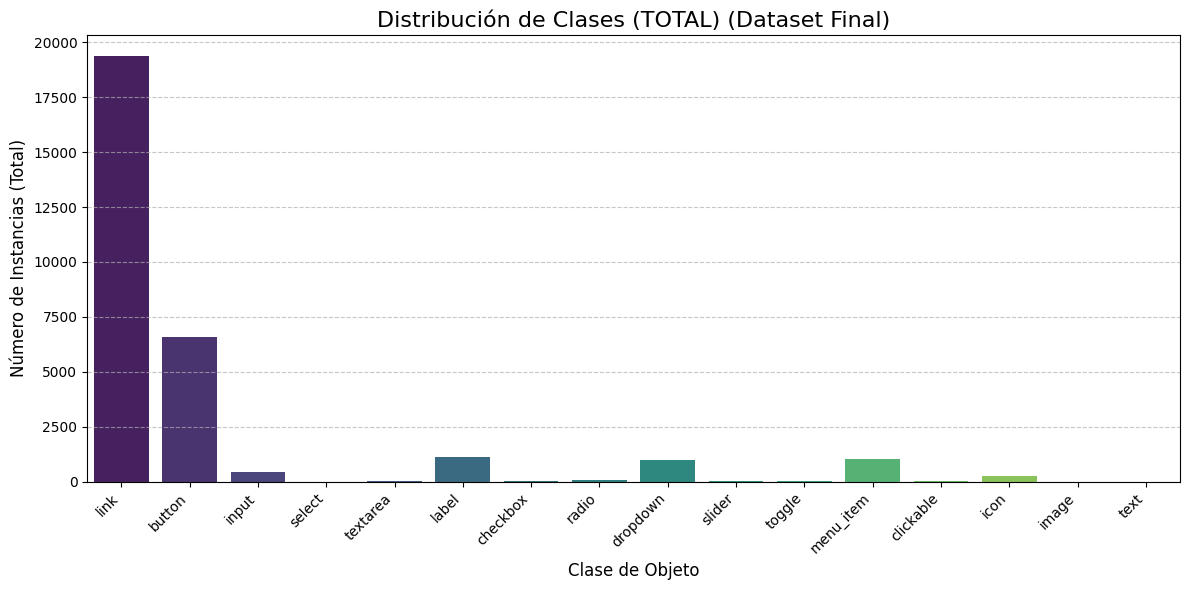

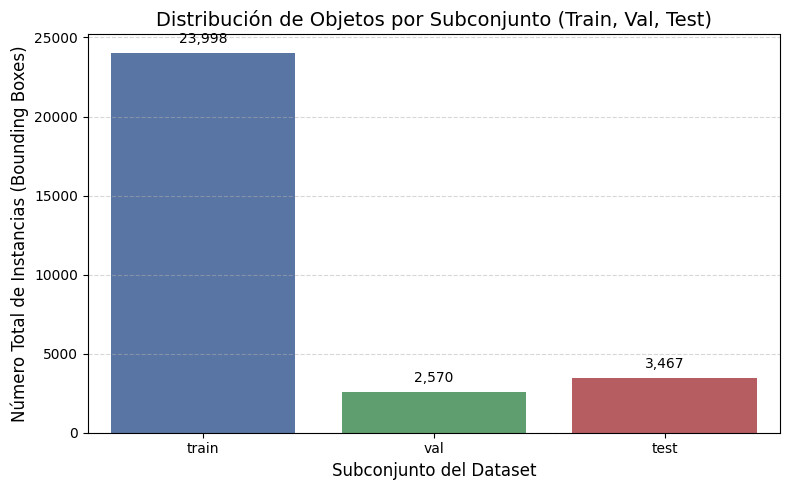

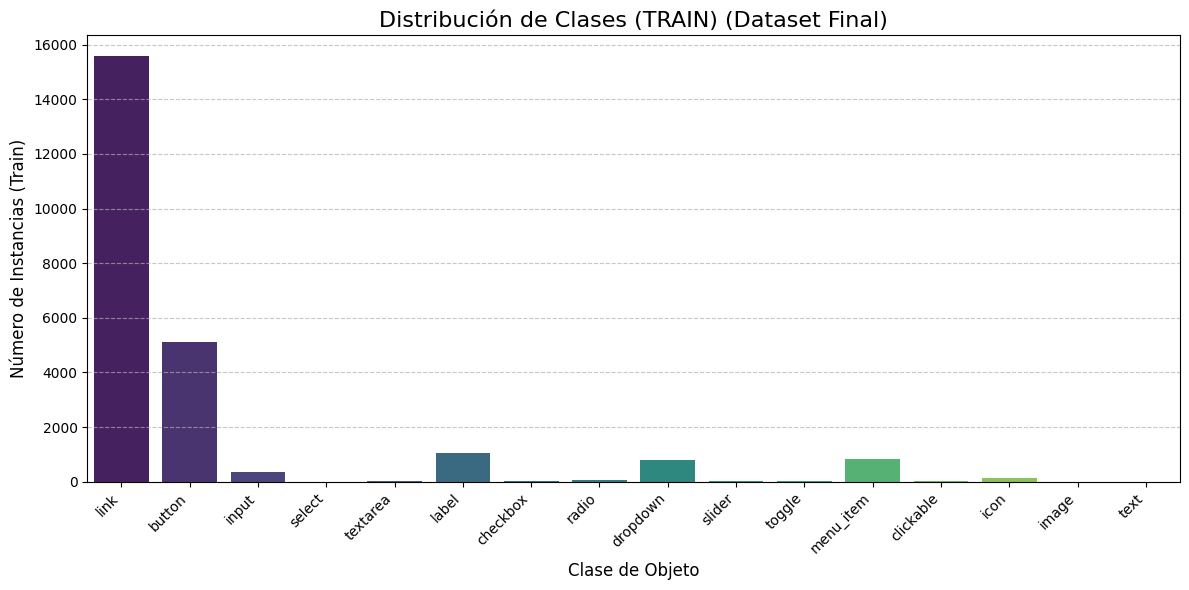

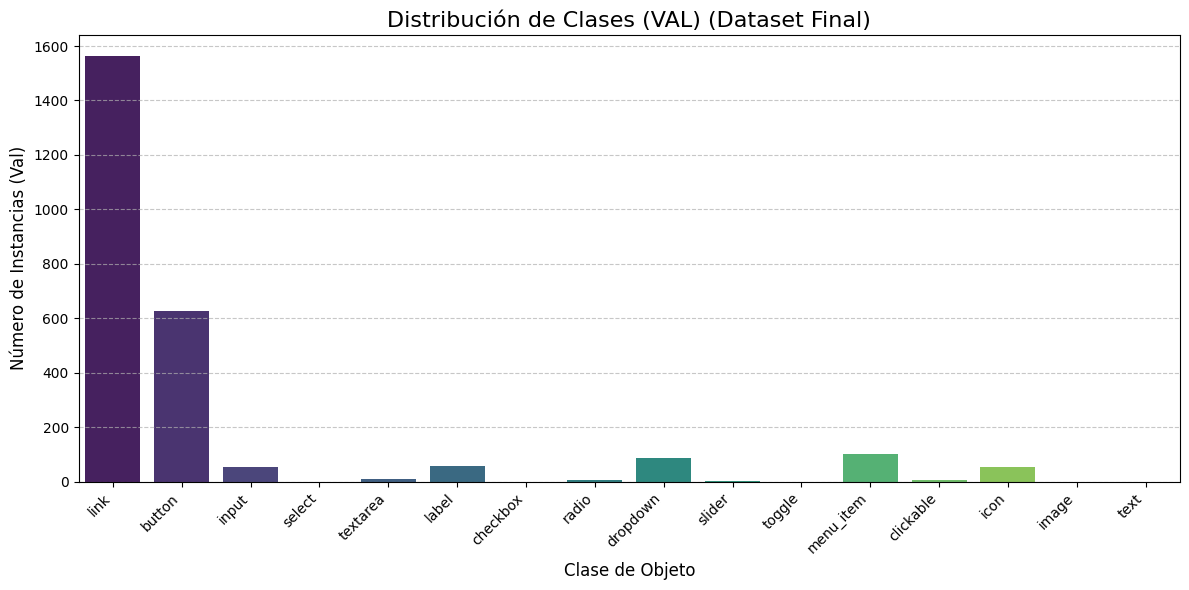

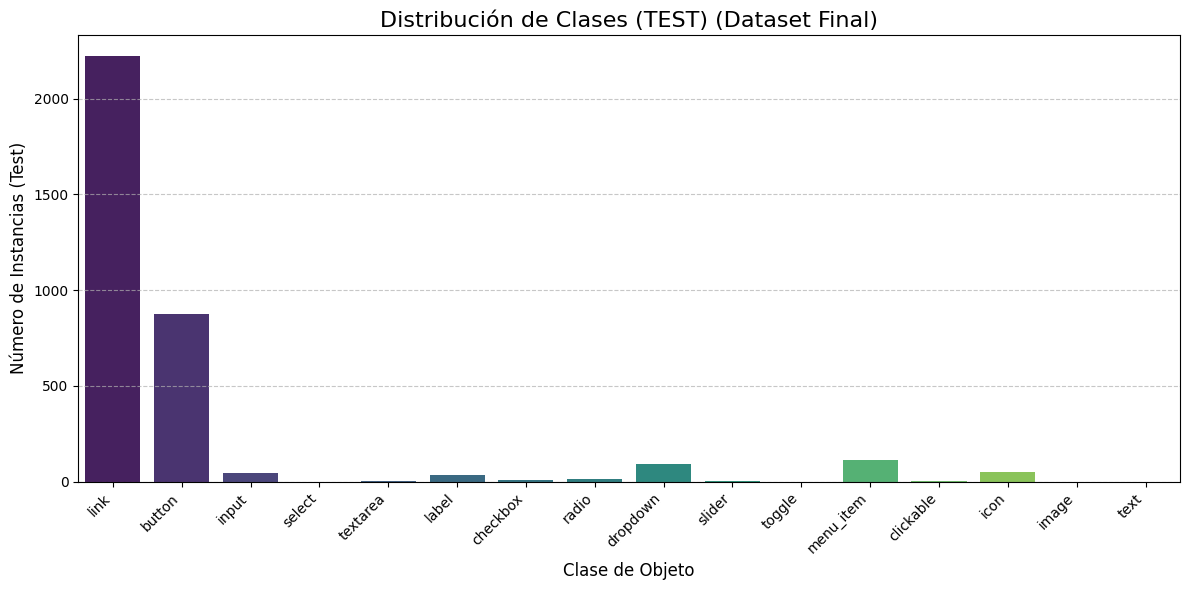


Observación clave sobre el desbalance en **TRAIN** (Dataset Final):
⚠️ **Clases No Representadas en TRAIN (0 instancias)**: select, image, text
La clase más frecuente (**link** con 15,583 instancias) tiene **1,947.88** veces más instancias que la menos frecuente (**toggle** con 8 instancias) en TRAIN.
🚨 **Desbalance SIGNIFICATIVO**: Se requiere aplicar técnicas robustas de balanceo (*oversampling*, *pérdida ponderada* o *Data Augmentation* avanzada).


In [39]:
dataset_path = "/content/dataset"

processor = Data_processing(dataset_path)
df_labels_for_eda = processor.run_analysis_descriptive(title_suffix="(Dataset Final)")

#


################################### ANÁLISIS EXPLORATORIO DE DATOS (EDA) ###################################

Análisis de Dimensiones de Bounding Boxes (EDA):
Nota: Se filtró el 1% superior de objetos por tamaño (W > 0.5251, H > 0.3866) para mejor visualización.


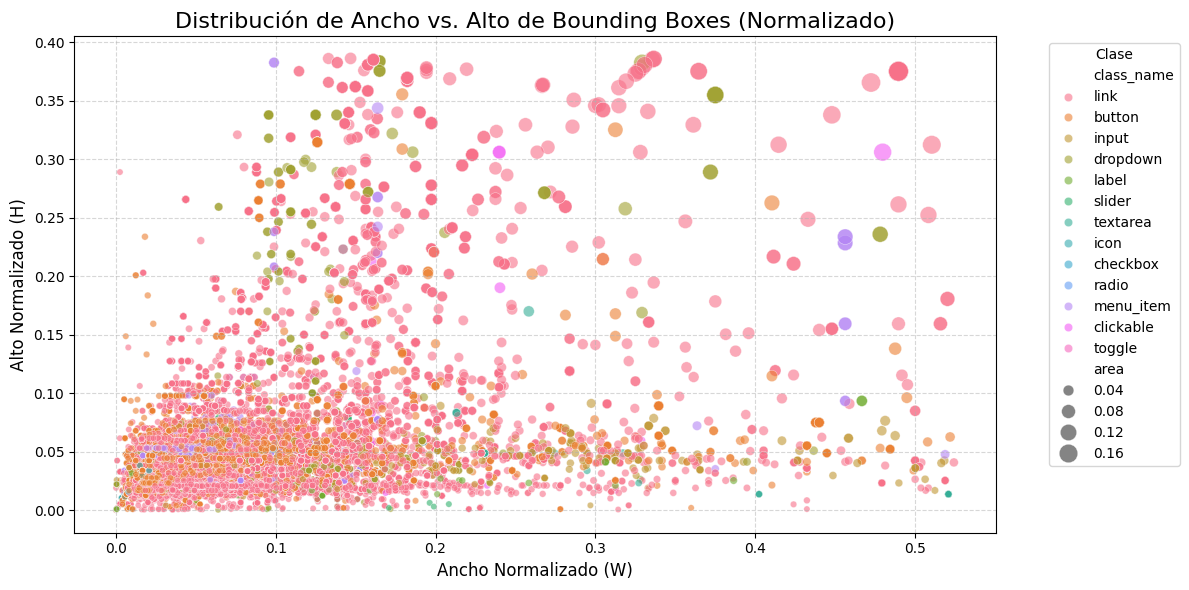

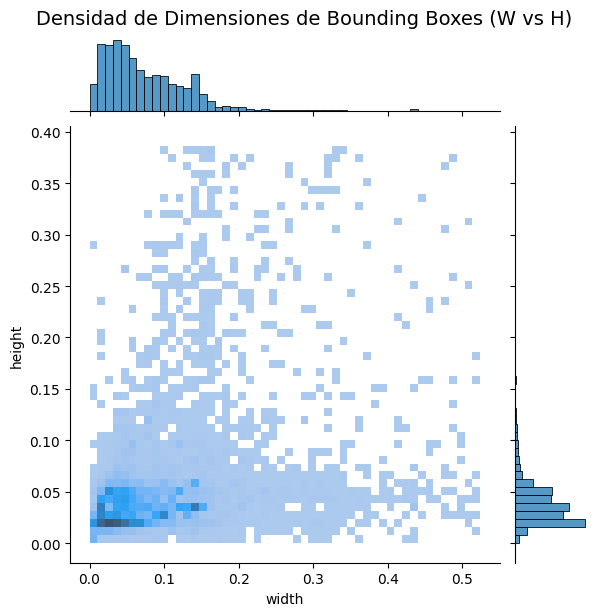

La agrupación de puntos en el Scatter Plot indica los tamaños de objetos que predominan y ayuda a optimizar los **Anclajes (Anchors)** del modelo YOLOv8.


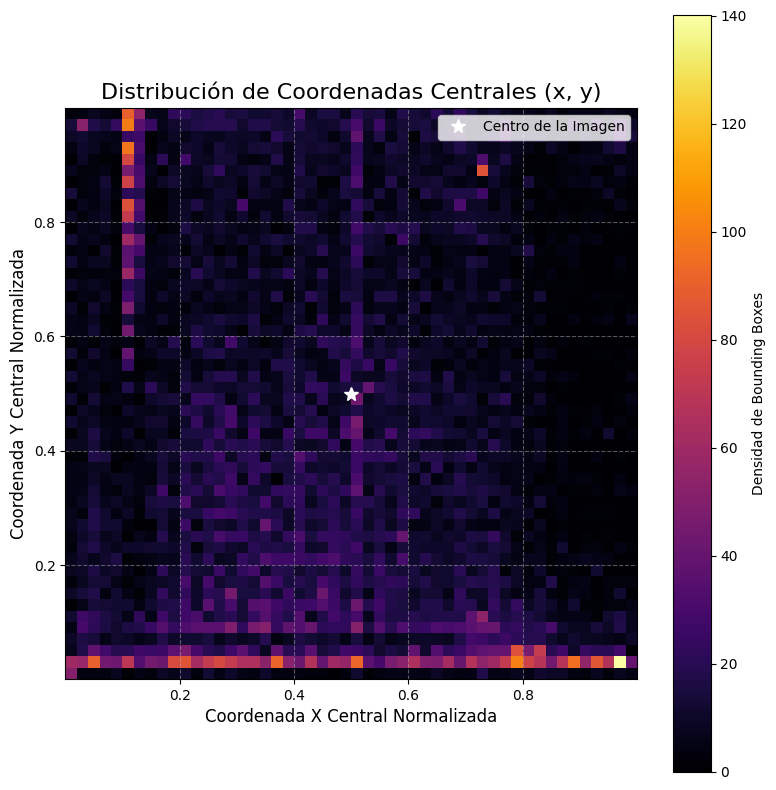

Este mapa de calor muestra si los objetos están sesgados a ciertas áreas de la pantalla, lo cual es común en interfaces web.


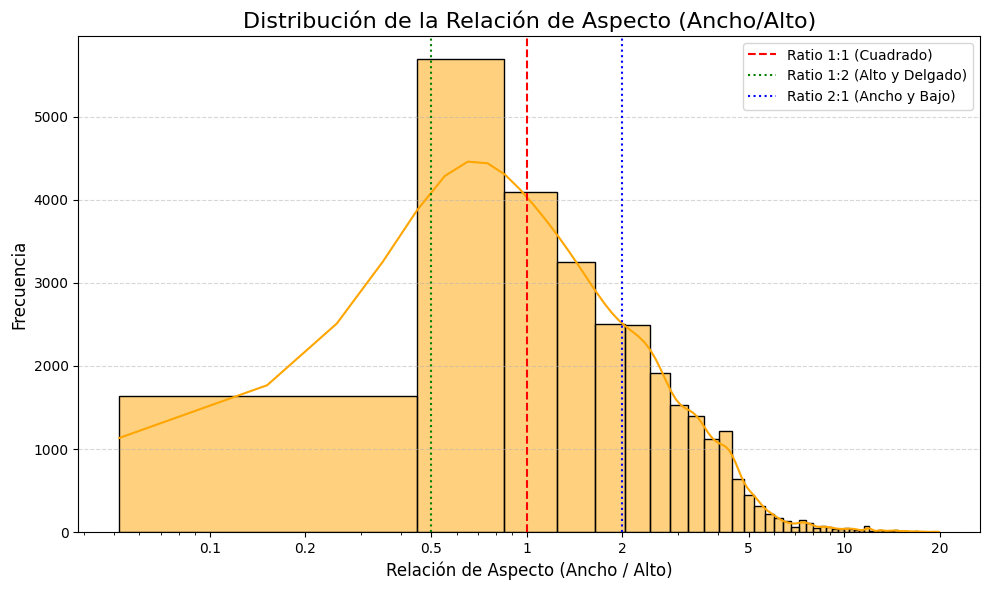


Interpretación de la Relación de Aspecto:
Los picos en este histograma indican las formas más comunes de los objetos (cuadrados, anchos, altos).
Esta información es vital para la selección o ajuste de los **anclajes (anchor boxes)** de tu modelo YOLOv8, asegurando que los anclajes predefinidos coincidan con las formas reales de los objetos en tus interfaces.


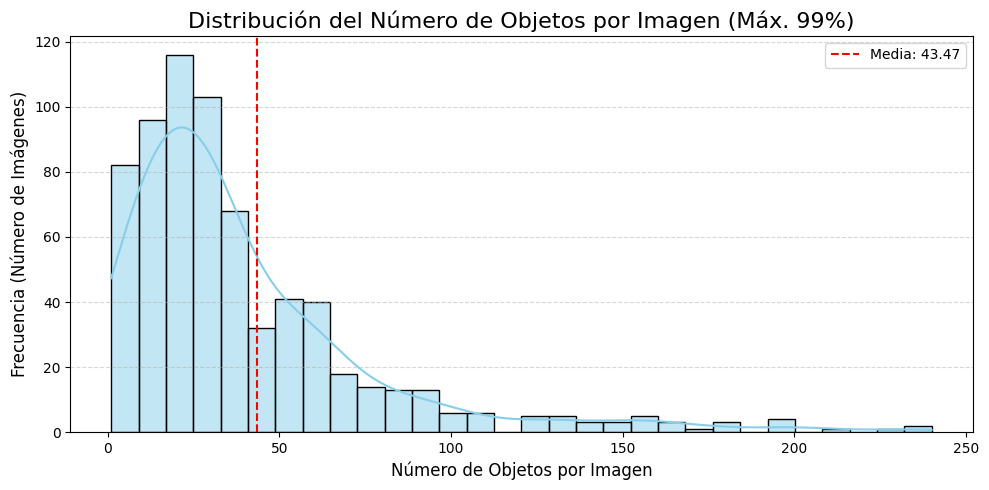

Media de objetos por imagen: 43.47. Esto define si el modelo debe ser optimizado para pocas o muchas detecciones por pantalla.


In [40]:
#analisis eda
processor.run_analysis_eda()